# 1. Load & explore dataset

In [1]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("tranthaihoa/vifactcheck")

In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence'],
        num_rows: 5062
    })
    dev: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence'],
        num_rows: 723
    })
    test: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence'],
        num_rows: 1447
    })
})

In [3]:
print("Number of unique topics:", len(set(ds['train']['Topic'])))

Number of unique topics: 52


In [4]:
set(ds['train']['Topic'])

{'AN NINH TRẬT TỰ',
 'Bạn đọc làm báo',
 'Bất động sản',
 'Chính trị',
 'Công nghệ',
 'Du lịch',
 'GIÁO DỤC',
 'GIẢI TRÍ',
 'GIỚI TRẺ',
 'Giáo dục',
 'Giáo dục - Hướng nghiệp',
 'Giải Trí',
 'Giải trí',
 'Giới trẻ',
 'HOA HẬU',
 'KHOA HỌC CÔNG NGHỆ',
 'KHOA HỌC',
 'KINH TẾ',
 'Khoa giáo',
 'Khoa học',
 'Kinh doanh',
 'Kinh tế',
 'NGƯỜI LÍNH',
 'NHỊP SỐNG PHƯƠNG NAM',
 'Nhà đất',
 'PHÁP LUẬT',
 'Pháp luật',
 'QUÂN SỰ',
 'QUỐC TẾ',
 'Quốc tế',
 'Số hóa',
 'SỨC KHỎE',
 'Sức khoẻ',
 'Sức khỏe',
 'THẾ GIỚI',
 'THỂ THAO',
 'THỜI SỰ',
 'Thế giới',
 'Thể thao',
 'Thời Sự',
 'Thời sự',
 'VĂN HOÁ',
 'VĂN HÓA',
 'Văn hoá',
 'Văn hóa',
 'XÃ HỘI',
 'Xã hội',
 'Y TẾ',
 'ĐÔ THỊ',
 'ĐỊA PHƯƠNG',
 'ĐỊA ỐC',
 'Đời sống'}

# 2. Preprocess

- The topics has many duplicates, so we group them into one topic.

In [5]:
new_topics_1 = {
    "THỜI SỰ": [
      "THỜI SỰ",
      "Thời Sự",
      "Thời sự"
    ],
    "THẾ GIỚI": [
      "THẾ GIỚI",
      "Thế giới",
      "QUỐC TẾ",
      "Quốc tế"
    ],
    "KINH TẾ": [
      "KINH TẾ",
      "Kinh tế",
      "Kinh doanh"
    ],
    "BẤT ĐỘNG SẢN": [
      "Bất động sản",
      "Nhà đất",
      "ĐỊA ỐC"
    ],
    "PHÁP LUẬT": [
      "PHÁP LUẬT",
      "Pháp luật",
      "AN NINH TRẬT TỰ"
    ],
    "GIÁO DỤC": [
      "GIÁO DỤC",
      "Giáo dục",
      "Giáo dục - Hướng nghiệp",
      "Khoa giáo"
    ],
    "KHOA HỌC CÔNG NGHỆ": [
      "KHOA HỌC",
      "Khoa học",
      "KHOA HỌC CÔNG NGHỆ", 
      "Công nghệ",
      "Số hóa"
    ],
    "SỨC KHỎE": [
      "SỨC KHỎE",
      "Sức khoẻ",
      "Sức khỏe",
      "Y TẾ"
    ],
    "VĂN HÓA": [
      "VĂN HOÁ",
      "VĂN HÓA",
      "Văn hoá",
      "Văn hóa"
    ],
    "GIẢI TRÍ": [
      "GIẢI TRÍ",
      "Giải Trí",
      "Giải trí",
      "HOA HẬU"
    ],
    "THỂ THAO": [
      "THỂ THAO",
      "Thể thao"
    ],
    "XÃ HỘI ĐỜI SỐNG": [
      "XÃ HỘI",
      "Xã hội",
      "Đời sống",
      "Bạn đọc làm báo",
      "NHỊP SỐNG PHƯƠNG NAM",
      "ĐỊA PHƯƠNG",
      "ĐÔ THỊ",
      "Nhịp sống trẻ"
    ],
    "QUÂN SỰ": [
      "QUÂN SỰ",
      "NGƯỜI LÍNH"
    ],
    "CHÍNH TRỊ": [
      "Chính trị"
    ],
    "GIỚI TRẺ": [
      "GIỚI TRẺ",
      "Giới trẻ"
    ],
    "DU LỊCH": [
      "Du lịch"
    ]
}

In [6]:
def map_topic_1(old_topic, new_topics):
    for new_topic, old_topics in new_topics.items():
        if old_topic in old_topics:
            return new_topic
    print("Cannot find proper topic mapping for ", old_topic)
    return old_topic

In [7]:
def generate_topics_1(row):
    row["New Topic 1"] = map_topic_1(row["Topic"], new_topics_1)
    return row

In [8]:
ds = ds.map(generate_topics_1)

In [9]:
from collections import Counter
stat_new_topics_1 = Counter(ds['train']['New Topic 1'])
stat_new_topics_1

Counter({'THẾ GIỚI': 654,
         'GIÁO DỤC': 640,
         'KINH TẾ': 474,
         'XÃ HỘI ĐỜI SỐNG': 461,
         'THỂ THAO': 401,
         'PHÁP LUẬT': 387,
         'VĂN HÓA': 384,
         'THỜI SỰ': 320,
         'SỨC KHỎE': 303,
         'KHOA HỌC CÔNG NGHỆ': 290,
         'GIẢI TRÍ': 227,
         'CHÍNH TRỊ': 198,
         'GIỚI TRẺ': 106,
         'DU LỊCH': 81,
         'BẤT ĐỘNG SẢN': 79,
         'QUÂN SỰ': 57})

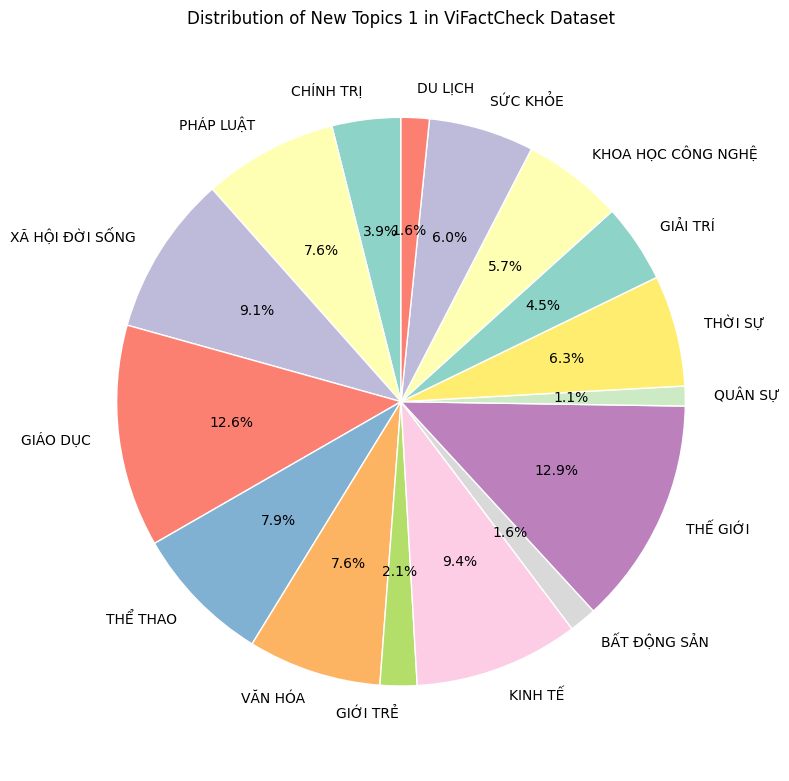

In [10]:
import matplotlib.pyplot as plt

labels = list(stat_new_topics_1.keys())
sizes = list(stat_new_topics_1.values())

fig, ax = plt.subplots(figsize=(8,8))

colors = plt.cm.Set3.colors  # colormap đẹp, dễ phân biệt

ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}  # viền trắng cho rõ
)

ax.axis('equal')
ax.set_title("Distribution of New Topics 1 in ViFactCheck Dataset", fontsize=12)

plt.tight_layout()
plt.show()


# 3. Group for better classification

## Analysis

- After merging **52 → 16 topics**, there are still **class imbalance** issues.
- Some classes have **very few samples** (e.g., **QUÂN SỰ = 57**, **DU LỊCH = 81**, **BẤT ĐỘNG SẢN = 79**).
- Certain classes show **semantic confusion** (e.g., **THỜI SỰ** vs. **XÃ HỘI ĐỜI SỐNG**).

## Merge Strategy (16 → 11 classes)

1. **BẤT ĐỘNG SẢN** (79) → **KINH TẾ**  
   *Bất động sản is a sub-domain of Kinh tế.*

2. **DU LỊCH** (81) → **VĂN HÓA**  
   *Du lịch content is often strongly related to Văn hóa.*

3. **GIỚI TRẺ** (106) → **XÃ HỘI ĐỜI SỐNG**  
   *Giới trẻ lifestyle topics are part of social life.*

4. **QUÂN SỰ** (57) → **THẾ GIỚI**  
   *Quân sự news is usually international/world-related.*

5. **THỜI SỰ** (320) → **XÃ HỘI ĐỜI SỐNG**  
   *Thời sự mainly reflects general social and daily-life issues.*

## Result

- Final dataset contains **11 classes** with improved balance.
- Reduced **confusion between semantically similar classes**.
- Better suitability for **text classification model training**.


In [11]:
# Mapping merge từ 16 classes → 11 classes (khớp với finetune_phobert_v3_merged.py)
LABEL_MERGE_MAPPING = {
    # Nhóm 1: Kinh tế & Thị trường
    "BẤT ĐỘNG SẢN": "KINH TẾ",  # Gộp vào KINH TẾ (79 + 474 = 553)
    
    # Nhóm 2: Văn hóa - Giải trí - Đời sống
    "DU LỊCH": "VĂN HÓA",  # Du lịch thường gắn với văn hóa (81 + 384 = 465)
    "GIỚI TRẺ": "XÃ HỘI ĐỜI SỐNG",  # Lối sống giới trẻ (106 + 461 = 567)
    
    # Nhóm 3: Chính trị - Xã hội - Thời sự
    "QUÂN SỰ": "THẾ GIỚI",  # Quân sự thường là tin quốc tế (57 + 654 = 711)
    "THỜI SỰ": "XÃ HỘI ĐỜI SỐNG",  # Thời sự tổng hợp -> Xã hội (320 + 567 = 887)
    
    # Các labels giữ nguyên (11 classes còn lại)
    "CHÍNH TRỊ": "CHÍNH TRỊ",
    "GIÁO DỤC": "GIÁO DỤC",
    "GIẢI TRÍ": "GIẢI TRÍ",
    "KHOA HỌC CÔNG NGHỆ": "KHOA HỌC CÔNG NGHỆ",
    "KINH TẾ": "KINH TẾ",
    "PHÁP LUẬT": "PHÁP LUẬT",
    "SỨC KHỎE": "SỨC KHỎE",
    "THẾ GIỚI": "THẾ GIỚI",
    "THỂ THAO": "THỂ THAO",
    "VĂN HÓA": "VĂN HÓA",
    "XÃ HỘI ĐỜI SỐNG": "XÃ HỘI ĐỜI SỐNG",
}

print("Label merging strategy (16 → 11 classes):")
print("  BẤT ĐỘNG SẢN (79) → KINH TẾ")
print("  DU LỊCH (81) → VĂN HÓA")
print("  GIỚI TRẺ (106) → XÃ HỘI ĐỜI SỐNG")
print("  QUÂN SỰ (57) → THẾ GIỚI")
print("  THỜI SỰ (320) → XÃ HỘI ĐỜI SỐNG")

Label merging strategy (16 → 11 classes):
  BẤT ĐỘNG SẢN (79) → KINH TẾ
  DU LỊCH (81) → VĂN HÓA
  GIỚI TRẺ (106) → XÃ HỘI ĐỜI SỐNG
  QUÂN SỰ (57) → THẾ GIỚI
  THỜI SỰ (320) → XÃ HỘI ĐỜI SỐNG


In [12]:
# Không cần nữa - đã thay bằng LABEL_MERGE_MAPPING ở cell trước

In [13]:
def merge_labels(example):
    """Gộp labels từ 16 → 11 classes theo LABEL_MERGE_MAPPING"""
    old_label = example["New Topic 1"]
    new_label = LABEL_MERGE_MAPPING.get(old_label, old_label)
    example["Merged Topic"] = new_label
    return example

In [14]:
print("Applying label merging (16 → 11 classes)...")
ds = ds.map(merge_labels)

Applying label merging (16 → 11 classes)...


Map:   0%|          | 0/5062 [00:00<?, ? examples/s]

Map:   0%|          | 0/723 [00:00<?, ? examples/s]

Map:   0%|          | 0/1447 [00:00<?, ? examples/s]

In [15]:
# Kiểm tra kết quả sau khi merge
stat_merged_topics = Counter(ds['train']['Merged Topic'])
print(f"\n✅ After merging: {len(stat_merged_topics)} classes")
print("\nDistribution after merging:")
for topic, count in stat_merged_topics.most_common():
    print(f"  {topic:25s}: {count:4d} samples")


✅ After merging: 11 classes

Distribution after merging:
  XÃ HỘI ĐỜI SỐNG          :  887 samples
  THẾ GIỚI                 :  711 samples
  GIÁO DỤC                 :  640 samples
  KINH TẾ                  :  553 samples
  VĂN HÓA                  :  465 samples
  THỂ THAO                 :  401 samples
  PHÁP LUẬT                :  387 samples
  SỨC KHỎE                 :  303 samples
  KHOA HỌC CÔNG NGHỆ       :  290 samples
  GIẢI TRÍ                 :  227 samples
  CHÍNH TRỊ                :  198 samples


In [16]:
stat_merged_topics

Counter({'XÃ HỘI ĐỜI SỐNG': 887,
         'THẾ GIỚI': 711,
         'GIÁO DỤC': 640,
         'KINH TẾ': 553,
         'VĂN HÓA': 465,
         'THỂ THAO': 401,
         'PHÁP LUẬT': 387,
         'SỨC KHỎE': 303,
         'KHOA HỌC CÔNG NGHỆ': 290,
         'GIẢI TRÍ': 227,
         'CHÍNH TRỊ': 198})

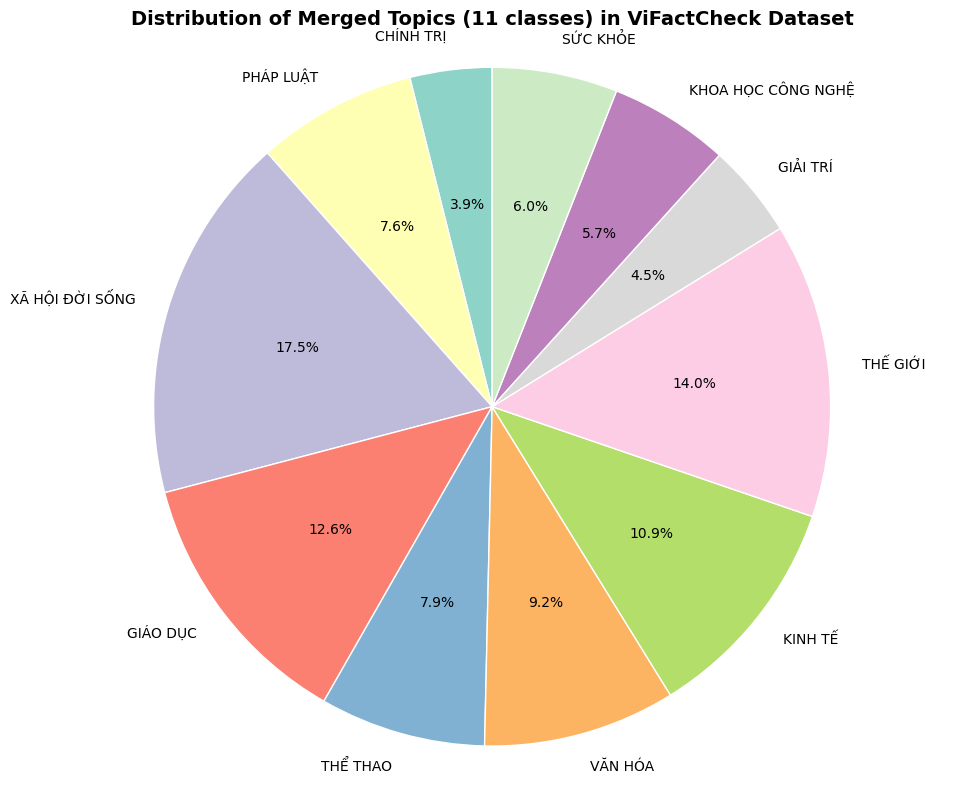


📊 Phân tích:
  - Số classes: 11
  - Class lớn nhất: 887 samples
  - Class nhỏ nhất: 198 samples
  - Trung bình: 460 samples/class


In [17]:
# Visualize distribution sau khi merge (11 classes)
import matplotlib.pyplot as plt

labels = list(stat_merged_topics.keys())
sizes = list(stat_merged_topics.values())

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set3.colors

ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

ax.axis('equal')
ax.set_title("Distribution of Merged Topics (11 classes) in ViFactCheck Dataset", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Phân tích:")
print(f"  - Số classes: {len(stat_merged_topics)}")
print(f"  - Class lớn nhất: {max(stat_merged_topics.values())} samples")
print(f"  - Class nhỏ nhất: {min(stat_merged_topics.values())} samples")
print(f"  - Trung bình: {sum(stat_merged_topics.values()) / len(stat_merged_topics):.0f} samples/class")

In [18]:
## Bước 3: Tạo label ID cho training

# Tạo mapping từ label name → ID (dùng cho model training)
unique_labels = sorted(list(set(ds['train']['Merged Topic'])))
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label to ID mapping:")
for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
    print(f"  {idx:2d}. {label}")

Label to ID mapping:
   0. CHÍNH TRỊ
   1. GIÁO DỤC
   2. GIẢI TRÍ
   3. KHOA HỌC CÔNG NGHỆ
   4. KINH TẾ
   5. PHÁP LUẬT
   6. SỨC KHỎE
   7. THẾ GIỚI
   8. THỂ THAO
   9. VĂN HÓA
  10. XÃ HỘI ĐỜI SỐNG


In [19]:
def add_label_id(row):
    """Thêm cột label_id cho training"""
    row["label_id"] = label2id[row["Merged Topic"]]
    return row

ds = ds.map(add_label_id)
print("✅ Added label_id column")

Map:   0%|          | 0/5062 [00:00<?, ? examples/s]

Map:   0%|          | 0/723 [00:00<?, ? examples/s]

Map:   0%|          | 0/1447 [00:00<?, ? examples/s]

✅ Added label_id column


In [20]:
ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence', 'New Topic 1', 'Merged Topic', 'label_id'],
        num_rows: 5062
    })
    dev: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence', 'New Topic 1', 'Merged Topic', 'label_id'],
        num_rows: 723
    })
    test: Dataset({
        features: ['Unnamed: 0', 'index', 'Statement', 'Context', 'annotation_id', 'Topic', 'Author', 'Url', 'labels', 'Evidence', 'New Topic 1', 'Merged Topic', 'label_id'],
        num_rows: 1447
    })
})

# 4. Push dataset to Hugging Face Hub

In [21]:
## Bước 4: Push to Hugging Face Hub

from huggingface_hub import notebook_login

notebook_login()

In [23]:
# Push dataset đã xử lý lên Hugging Face Hub
print("Pushing dataset to Hugging Face Hub...")
ds.push_to_hub("hihihohohehe/vifactcheck-normalized")
print("✅ Dataset uploaded successfully!")

Pushing dataset to Hugging Face Hub...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

README.md: 0.00B [00:00, ?B/s]

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acer\.cache\huggingface\hub\datasets--hihihohohehe--vifactcheck-normalized. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
No files have been modified since last commit. Skipping to prevent empty commi

✅ Dataset uploaded successfully!
